# Fisher–KPP on Graphs — Group 1: Traveling Wave Speed

## Overview

This notebook simulates the **Fisher–KPP equation**

$$\partial_t u = \partial_{xx} u + u(1-u)$$

on three graph geometries and estimates the **traveling wave speed**.

| Graph | Structure |
|-------|-----------|
| **Graph 1 – Star** | $n$ incoming + $m$ outgoing, one vertex |
| **Graph 2 – Extended Star** | $n$ incoming + middle edge + $m$ outgoing, two vertices |
| **Graph 3 – Tadpole** | 1 incoming + 2 loop edges + 1 outgoing, two vertices |

**Vertex conditions at every junction:**
- Continuity: all edges share the same value $U_v$
- Neumann–Kirchhoff: $\sum_{\text{edges}} \partial_n u = 0$ (current conservation)

**Speed estimation methods:**
- (A) **Level-set tracking** — track $x_{0.5}(t)$ and fit slope $c = dx_{0.5}/dt$
- (B) **Instantaneous speed** — finite-difference derivative of level-set position
- (C) **$\lambda$-study** — vary initial decay $\lambda$, compare to $c(\lambda)=\lambda+1/\lambda$


## Cell 1 — Imports & parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import os, warnings
warnings.filterwarnings('ignore')

# Spatial grid
L      = 25.0
L_MID  = 5.0
DX     = 0.10
N      = int(round(L     / DX))   # = 250
N_MID  = int(round(L_MID / DX))   # =  50

# Time integration
DT     = 0.004
T_END  = 12.0
N_SNAP = 30

# Default graph shape
N_IN  = 2
N_OUT = 3

# Coordinate arrays
X_IN  = np.linspace(-L,    0,      N     + 1)
X_OUT = np.linspace( 0,    L,      N     + 1)
X_MID = np.linspace( 0,    L_MID,  N_MID + 1)

os.makedirs('output', exist_ok=True)
print(f"Grid : DX={DX},  N={N},  N_MID={N_MID}")
print(f"Time : DT={DT},  T_END={T_END},  CFL={DT/DX**2:.3f}  (must be < 0.5)")
print(f"Graph: n={N_IN} incoming,  m={N_OUT} outgoing")


Grid : DX=0.1,  N=250,  N_MID=50
Time : DT=0.004,  T_END=12.0,  CFL=0.400  (must be < 0.5)
Graph: n=2 incoming,  m=3 outgoing


## Cell 2 — Edge RHS (Fisher–KPP on one 1-D edge)

Each edge obeys $\partial_t u = \partial_{xx} u + u(1-u)$.

**Interior:** central differences. **Outer Neumann:** ghost-point trick. **Vertex end:** set to 0, overridden algebraically each step.


In [2]:
def edge_rhs(u, dx, left='neumann', right='neumann'):
    f = np.empty_like(u)
    f[1:-1] = (u[:-2] - 2.0*u[1:-1] + u[2:]) / dx**2 + u[1:-1] * (1.0 - u[1:-1])
    f[0]  = 2.0*(u[1]  - u[0])  / dx**2 + u[0]  * (1.0 - u[0])  if left  == 'neumann' else 0.0
    f[-1] = 2.0*(u[-2] - u[-1]) / dx**2 + u[-1] * (1.0 - u[-1]) if right == 'neumann' else 0.0
    return f

print("edge_rhs defined  ok")


edge_rhs defined  ok


## Cell 3 — Graph 1: Star Graph simulator

**Kirchhoff at vertex:** $(n+m)\,U_v = \sum_i u_i[N-1] + \sum_j u_j[1]$


In [3]:
def simulate_star(n, m, U_in_0, U_out_0, T=T_END, dt=DT, verbose=True):
    U_in  = [u.copy() for u in U_in_0]
    U_out = [u.copy() for u in U_out_0]
    Uv0 = (sum(u[-2] for u in U_in) + sum(u[1] for u in U_out)) / (n + m)
    for u in U_in:  u[-1] = Uv0
    for u in U_out: u[ 0] = Uv0

    snap_times = np.linspace(0, T, N_SNAP + 1)
    snapshots  = []
    t = 0.0;  si = 0;  step = 0
    report = max(1, int(T / dt) // 4)

    while t <= T + 1e-10:
        if step == 0 or (si <= N_SNAP and t >= snap_times[si] - 1e-12):
            snapshots.append((t, [u.copy() for u in U_in], [u.copy() for u in U_out]))
            si = min(si + 1, N_SNAP)
        if t >= T:
            break
        dU_in  = [edge_rhs(u, DX, left='neumann', right='vertex') for u in U_in]
        dU_out = [edge_rhs(u, DX, left='vertex',  right='neumann') for u in U_out]
        U_in  = [U_in[k]  + dt * dU_in[k]  for k in range(n)]
        U_out = [U_out[k] + dt * dU_out[k] for k in range(m)]
        Uv = (sum(u[-2] for u in U_in) + sum(u[1] for u in U_out)) / (n + m)
        for u in U_in:  u[-1] = Uv
        for u in U_out: u[ 0] = Uv
        t += dt;  step += 1
        if verbose and step % report == 0:
            print(f"  t={t:.1f}/{T:.0f}  Uv={Uv:.4f}")
    return snapshots

print("simulate_star defined  ok")


simulate_star defined  ok


## Cell 4 — Graph 2: Extended Star Graph simulator

**Left vertex:** $(n+1)\,U_{vL} = \sum_i u_i[N-1] + u_{\text{mid}}[1]$

**Right vertex:** $(m+1)\,U_{vR} = u_{\text{mid}}[N_m-1] + \sum_j u_j[1]$


In [4]:
def simulate_extended_star(n, m, U_in_0, U_mid_0, U_out_0, T=T_END, dt=DT, verbose=True):
    U_in  = [u.copy() for u in U_in_0]
    U_mid = U_mid_0.copy()
    U_out = [u.copy() for u in U_out_0]
    UvL0 = (sum(u[-2] for u in U_in) + U_mid[1])  / (n + 1)
    UvR0 = (U_mid[-2] + sum(u[1] for u in U_out)) / (m + 1)
    for u in U_in: u[-1]  = UvL0
    U_mid[0] = UvL0;  U_mid[-1] = UvR0
    for u in U_out: u[0]  = UvR0

    snap_times = np.linspace(0, T, N_SNAP + 1)
    snapshots  = []
    t = 0.0;  si = 0;  step = 0
    report = max(1, int(T / dt) // 4)

    while t <= T + 1e-10:
        if step == 0 or (si <= N_SNAP and t >= snap_times[si] - 1e-12):
            snapshots.append((t, [u.copy() for u in U_in], U_mid.copy(), [u.copy() for u in U_out]))
            si = min(si + 1, N_SNAP)
        if t >= T:
            break
        dU_in  = [edge_rhs(u,    DX, left='neumann', right='vertex') for u in U_in]
        dU_mid = edge_rhs(U_mid, DX, left='vertex',  right='vertex')
        dU_out = [edge_rhs(u,    DX, left='vertex',  right='neumann') for u in U_out]
        U_in  = [U_in[k]  + dt * dU_in[k]  for k in range(n)]
        U_mid = U_mid + dt * dU_mid
        U_out = [U_out[k] + dt * dU_out[k] for k in range(m)]
        UvL = (sum(u[-2] for u in U_in) + U_mid[1])  / (n + 1)
        for u in U_in: u[-1] = UvL
        U_mid[0] = UvL
        UvR = (U_mid[-2] + sum(u[1] for u in U_out)) / (m + 1)
        U_mid[-1] = UvR
        for u in U_out: u[0] = UvR
        t += dt;  step += 1
        if verbose and step % report == 0:
            print(f"  t={t:.1f}/{T:.0f}  vL={UvL:.4f}  vR={UvR:.4f}")
    return snapshots

print("simulate_extended_star defined  ok")


simulate_extended_star defined  ok


## Cell 5 — Graph 3: Tadpole Graph simulator

**Left vertex (1 in, 2 out):** $3\,U_{vL} = u_{\text{in}}[N-1] + u_{m1}[1] + u_{m2}[1]$

**Right vertex (2 in, 1 out):** $3\,U_{vR} = u_{m1}[N-1] + u_{m2}[N-1] + u_{\text{out}}[1]$


In [5]:
def simulate_tadpole(u_in_0, u_m1_0, u_m2_0, u_out_0, T=T_END, dt=DT, verbose=True):
    u_in  = u_in_0.copy();  u_m1  = u_m1_0.copy()
    u_m2  = u_m2_0.copy();  u_out = u_out_0.copy()
    UvL0 = (u_in[-2]  + u_m1[1]  + u_m2[1])  / 3.0
    UvR0 = (u_m1[-2]  + u_m2[-2] + u_out[1]) / 3.0
    u_in[-1] = UvL0
    u_m1[0]  = UvL0;  u_m1[-1] = UvR0
    u_m2[0]  = UvL0;  u_m2[-1] = UvR0
    u_out[0] = UvR0

    snap_times = np.linspace(0, T, N_SNAP + 1)
    snapshots  = []
    t = 0.0;  si = 0;  step = 0
    report = max(1, int(T / dt) // 4)

    while t <= T + 1e-10:
        if step == 0 or (si <= N_SNAP and t >= snap_times[si] - 1e-12):
            snapshots.append((t, u_in.copy(), u_m1.copy(), u_m2.copy(), u_out.copy()))
            si = min(si + 1, N_SNAP)
        if t >= T:
            break
        du_in  = edge_rhs(u_in,  DX, left='neumann', right='vertex')
        du_m1  = edge_rhs(u_m1,  DX, left='vertex',  right='vertex')
        du_m2  = edge_rhs(u_m2,  DX, left='vertex',  right='vertex')
        du_out = edge_rhs(u_out, DX, left='vertex',  right='neumann')
        u_in  += dt * du_in;   u_m1 += dt * du_m1
        u_m2  += dt * du_m2;  u_out += dt * du_out
        UvL = (u_in[-2] + u_m1[1] + u_m2[1]) / 3.0
        u_in[-1] = UvL;  u_m1[0] = UvL;  u_m2[0] = UvL
        UvR = (u_m1[-2] + u_m2[-2] + u_out[1]) / 3.0
        u_m1[-1] = UvR;  u_m2[-1] = UvR;  u_out[0] = UvR
        t += dt;  step += 1
        if verbose and step % report == 0:
            print(f"  t={t:.1f}/{T:.0f}  vL={UvL:.4f}  vR={UvR:.4f}")
    return snapshots

print("simulate_tadpole defined  ok")


simulate_tadpole defined  ok


## Cell 6 — Initial data

| Type | Incoming | Outgoing / middle |
|------|----------|-------------------|
| **Type 1** | $u_0 = 1$ | $u_0 = 0$ |
| **Type 2** | $u_0 = 1$ | $u_0 = e^{-\lambda x}$ |


In [6]:
def make_star_type1(n, m):
    return [np.ones(N+1) for _ in range(n)], [np.zeros(N+1) for _ in range(m)]

def make_star_type2(n, m, lam):
    return [np.ones(N+1) for _ in range(n)], [np.exp(-lam * X_OUT) for _ in range(m)]

def make_ext_type1(n, m):
    return ([np.ones(N+1)  for _ in range(n)],
            np.full(N_MID+1, 0.5),
            [np.zeros(N+1) for _ in range(m)])

def make_ext_type2(n, m, lam):
    return ([np.ones(N+1) for _ in range(n)],
            np.exp(-lam * X_MID),
            [np.exp(-lam * (L_MID + X_OUT)) for _ in range(m)])

def make_tad_type1():
    return np.ones(N+1), np.full(N_MID+1, 0.5), np.full(N_MID+1, 0.5), np.zeros(N+1)

def make_tad_type2(lam):
    return (np.ones(N+1), np.exp(-lam * X_MID),
            np.exp(-lam * X_MID), np.exp(-lam * (L_MID + X_OUT)))

print("Initial data factories defined  ok")


Initial data factories defined  ok


## Cell 7 — Speed estimation: level-set tracking

At each snapshot find $x_{0.5}(t)$ on the outgoing edge, then fit $x_{0.5} = c\,t + b$.


In [7]:
def level_set_speed(snapshots, get_out, threshold=0.5, t_frac=0.35):
    times = [];  positions = []
    for snap in snapshots:
        t = snap[0]
        u = get_out(snap)
        if u.max() <= threshold or u.min() >= threshold:
            continue
        idx = np.where(u <= threshold)[0]
        if len(idx) == 0 or idx[0] == 0:
            continue
        i = idx[0]
        x_front = X_OUT[i-1] + (threshold - u[i-1]) / (u[i] - u[i-1]) * DX
        times.append(t);  positions.append(x_front)
    if len(times) < 4:
        return np.array(times), np.array(positions), np.nan
    times     = np.array(times)
    positions = np.array(positions)
    t_cut  = t_frac * times[-1]
    mask   = times >= t_cut
    if mask.sum() < 3:
        mask = np.ones(len(times), dtype=bool)
    speed = np.polyfit(times[mask], positions[mask], 1)[0]
    return times, positions, speed

def theoretical_speed(lam):
    return np.maximum(2.0, lam + 1.0 / lam)

print("level_set_speed defined  ok")


level_set_speed defined  ok


## Cell 8 — 3D plotting utilities

Each graph is visualised in **3D**: the physical graph geometry is laid out in the
$xy$-plane, and the solution $u$ is the $z$-axis. Vertices are marked as black dots.
Three time snapshots are shown side-by-side, matching the project's visual style.

**Edge colour scheme (consistent across all graphs):**
- Incoming edges: shades of **blue**
- Middle edges: shades of **green**
- Outgoing edges: shades of **red** / **orange**


In [8]:
# ── Shared style ─────────────────────────────────────────────────────────────
EDGE_STYLES = {
    'in':  ['#1f77b4', '#17becf', '#aec7e8'],   # blues
    'mid': ['#2ca02c', '#98df8a'],               # greens
    'out': ['#d62728', '#ff7f0e', '#ffbb78'],    # reds / oranges
}

def _find_snaps(snapshots, times_to_plot):
    all_t = np.array([s[0] for s in snapshots])
    return [int(np.argmin(np.abs(all_t - t))) for t in times_to_plot]

def _style_ax3d(ax, title):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('x', labelpad=4)
    ax.set_ylabel('y', labelpad=4)
    ax.set_zlabel('u', labelpad=4)
    ax.set_zlim(-0.05, 1.15)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=25, azim=-60)

def _vertex_dot(ax, vx, vy, u_val):
    ax.scatter([vx], [vy], [u_val], color='black', s=60, zorder=10, depthshade=False)

# ── GRAPH 1: Star ─────────────────────────────────────────────────────────────
def _star_geometry(n, m, L_edge=L):
    v = np.zeros(2)
    # Incoming: fan on left side (120 deg to 240 deg)
    in_angs  = np.linspace(120, 240, n) if n > 1 else np.array([180.0])
    # Outgoing: fan on right side (-60 deg to 60 deg)
    out_angs = np.linspace(-60, 60, m) if m > 1 else np.array([0.0])
    edges = []
    for ang in in_angs:
        r = np.radians(ang)
        d = np.array([np.cos(r), np.sin(r)])
        # Outer end -> vertex: parameter goes from 1 to 0 along d
        xs = v[0] + L_edge * d[0] * np.linspace(1, 0, N+1)
        ys = v[1] + L_edge * d[1] * np.linspace(1, 0, N+1)
        edges.append(('in', xs, ys))
    for ang in out_angs:
        r = np.radians(ang)
        d = np.array([np.cos(r), np.sin(r)])
        xs = v[0] + L_edge * d[0] * np.linspace(0, 1, N+1)
        ys = v[1] + L_edge * d[1] * np.linspace(0, 1, N+1)
        edges.append(('out', xs, ys))
    return v, edges

def plot_star_3d(snapshots, n, m, times_to_plot=(0, 3, 7),
                 title='Star Graph', fname=None):
    v, edges = _star_geometry(n, m)
    idxs = _find_snaps(snapshots, times_to_plot)
    fig = plt.figure(figsize=(6 * len(times_to_plot), 6))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    in_colors  = EDGE_STYLES['in'][:n]
    out_colors = EDGE_STYLES['out'][:m]

    for pi, si in enumerate(idxs):
        snap = snapshots[si]
        t_val, U_in, U_out = snap[0], snap[1], snap[2]
        ax = fig.add_subplot(1, len(times_to_plot), pi+1, projection='3d')
        _style_ax3d(ax, f't = {t_val:.2f}')

        in_i = out_i = 0
        for etype, xs, ys in edges:
            if etype == 'in':
                u_vals = U_in[in_i]
                color  = in_colors[in_i % len(in_colors)]
                label  = f'Edge {in_i+1} (in)' if pi == 0 else None
                in_i  += 1
            else:
                u_vals = U_out[out_i]
                color  = out_colors[out_i % len(out_colors)]
                label  = f'Edge {n+out_i+1} (out)' if pi == 0 else None
                out_i += 1
            ax.plot(xs, ys, u_vals, color=color, lw=2, label=label)

        _vertex_dot(ax, v[0], v[1], U_in[0][-1])
        if pi == 0:
            ax.legend(loc='upper left', fontsize=8, framealpha=0.7)

    plt.tight_layout()
    if fname: fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# ── GRAPH 2: Extended Star ────────────────────────────────────────────────────
def _ext_geometry(n, m, L_edge=L, Lm=L_MID):
    vL = np.array([0.0, 0.0])
    vR = np.array([Lm,  0.0])
    in_angs  = np.linspace(120, 240, n) if n > 1 else np.array([180.0])
    out_angs = np.linspace(-60, 60, m) if m > 1 else np.array([0.0])
    edges = []
    for ang in in_angs:
        r = np.radians(ang)
        d = np.array([np.cos(r), np.sin(r)])
        xs = vL[0] + L_edge * d[0] * np.linspace(1, 0, N+1)
        ys = vL[1] + L_edge * d[1] * np.linspace(1, 0, N+1)
        edges.append(('in', xs, ys))
    # Middle edge: vL -> vR along x-axis
    xs_mid = np.linspace(vL[0], vR[0], N_MID+1)
    ys_mid = np.zeros(N_MID+1)
    edges.append(('mid', xs_mid, ys_mid))
    for ang in out_angs:
        r = np.radians(ang)
        d = np.array([np.cos(r), np.sin(r)])
        xs = vR[0] + L_edge * d[0] * np.linspace(0, 1, N+1)
        ys = vR[1] + L_edge * d[1] * np.linspace(0, 1, N+1)
        edges.append(('out', xs, ys))
    return vL, vR, edges

def plot_extended_star_3d(snapshots, n, m, times_to_plot=(0, 3, 7),
                          title='Extended Star', fname=None):
    vL, vR, edges = _ext_geometry(n, m)
    idxs = _find_snaps(snapshots, times_to_plot)
    fig  = plt.figure(figsize=(6 * len(times_to_plot), 6))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    in_colors  = EDGE_STYLES['in'][:n]
    mid_colors = EDGE_STYLES['mid']
    out_colors = EDGE_STYLES['out'][:m]

    for pi, si in enumerate(idxs):
        snap = snapshots[si]
        t_val, U_in, U_mid, U_out = snap[0], snap[1], snap[2], snap[3]
        ax = fig.add_subplot(1, len(times_to_plot), pi+1, projection='3d')
        _style_ax3d(ax, f't = {t_val:.2f}')

        in_i = out_i = 0
        for etype, xs, ys in edges:
            if etype == 'in':
                u_vals = U_in[in_i]
                color  = in_colors[in_i % len(in_colors)]
                label  = f'Incoming {in_i+1}' if pi == 0 else None
                in_i  += 1
            elif etype == 'mid':
                u_vals = U_mid
                color  = mid_colors[0]
                label  = 'Middle' if pi == 0 else None
            else:
                u_vals = U_out[out_i]
                color  = out_colors[out_i % len(out_colors)]
                label  = f'Outgoing {out_i+1}' if pi == 0 else None
                out_i += 1
            ax.plot(xs, ys, u_vals, color=color, lw=2, label=label)

        # Both vertices
        _vertex_dot(ax, vL[0], vL[1], U_in[0][-1])
        _vertex_dot(ax, vR[0], vR[1], U_out[0][0])
        if pi == 0:
            ax.legend(loc='upper left', fontsize=8, framealpha=0.7)

    plt.tight_layout()
    if fname: fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# ── GRAPH 3: Tadpole ──────────────────────────────────────────────────────────
def _tadpole_geometry(L_edge=L, Lm=L_MID):
    r = Lm / 2.0                           # radius of loop semicircles
    vL = np.array([-r, 0.0])
    vR = np.array([ r, 0.0])
    # Incoming: from far left toward vL (along negative x)
    xs_in = np.linspace(vL[0] - L_edge, vL[0], N+1)
    ys_in = np.zeros(N+1)
    # Loop 1 (upper semicircle): vL -> vR going through top
    theta1 = np.linspace(np.pi, 0, N_MID+1)   # 180 deg -> 0 deg
    xs_m1  = r * np.cos(theta1)
    ys_m1  = r * np.sin(theta1)               # positive y = upper
    # Loop 2 (lower semicircle): vL -> vR going through bottom
    theta2 = np.linspace(np.pi, 2*np.pi, N_MID+1)
    xs_m2  = r * np.cos(theta2)
    ys_m2  = r * np.sin(theta2)               # negative y = lower
    # Outgoing: from vR toward far right
    xs_out = np.linspace(vR[0], vR[0] + L_edge, N+1)
    ys_out = np.zeros(N+1)
    return vL, vR, xs_in, ys_in, xs_m1, ys_m1, xs_m2, ys_m2, xs_out, ys_out

def plot_tadpole_3d(snapshots, times_to_plot=(0, 3, 7),
                    title='Tadpole Graph', fname=None):
    geom = _tadpole_geometry()
    vL, vR = geom[0], geom[1]
    xs_in, ys_in   = geom[2],  geom[3]
    xs_m1, ys_m1   = geom[4],  geom[5]
    xs_m2, ys_m2   = geom[6],  geom[7]
    xs_out, ys_out = geom[8],  geom[9]

    idxs = _find_snaps(snapshots, times_to_plot)
    fig  = plt.figure(figsize=(6 * len(times_to_plot), 6))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    c_in  = EDGE_STYLES['in'][0]
    c_m1  = EDGE_STYLES['mid'][0]
    c_m2  = EDGE_STYLES['mid'][1]
    c_out = EDGE_STYLES['out'][0]

    for pi, si in enumerate(idxs):
        snap = snapshots[si]
        t_val, u_in, u_m1, u_m2, u_out = snap
        ax = fig.add_subplot(1, len(times_to_plot), pi+1, projection='3d')
        _style_ax3d(ax, f't = {t_val:.2f}')

        ax.plot(xs_in,  ys_in,  u_in,  color=c_in,  lw=2, label='Incoming'   if pi == 0 else None)
        ax.plot(xs_m1,  ys_m1,  u_m1,  color=c_m1,  lw=2, label='Loop upper' if pi == 0 else None)
        ax.plot(xs_m2,  ys_m2,  u_m2,  color=c_m2,  lw=2, label='Loop lower' if pi == 0 else None)
        ax.plot(xs_out, ys_out, u_out, color=c_out, lw=2, label='Outgoing'   if pi == 0 else None)

        _vertex_dot(ax, vL[0], vL[1], u_in[-1])
        _vertex_dot(ax, vR[0], vR[1], u_out[0])
        if pi == 0:
            ax.legend(loc='upper left', fontsize=8, framealpha=0.7)

    plt.tight_layout()
    if fname: fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# 2D colormap helpers (used for speed/spacetime plots)
CMAP   = cm.plasma
COLORS = ['#e41a1c', '#377eb8', '#4daf4a']

def snap_colors(n):
    return [CMAP(i / max(n-1, 1)) for i in range(n)]

def add_colorbar(fig, axes):
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(0, T_END))
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label='time  t', shrink=0.75, pad=0.02)

print("3D plotting utilities defined  ok")


3D plotting utilities defined  ok


## Cell 9 — Simulate & plot Graph 1: Star Graph

Three time snapshots shown in 3D. The graph fans out from the central vertex:
incoming edges (blue) on the left, outgoing (red/orange) on the right.


  Star Graph  (n=2 incoming,  m=3 outgoing)

--- Type 1: step initial data ---
  t=3.0/12  Uv=0.8231
  t=6.0/12  Uv=0.9749
  t=9.0/12  Uv=0.9972
  t=12.0/12  Uv=0.9997


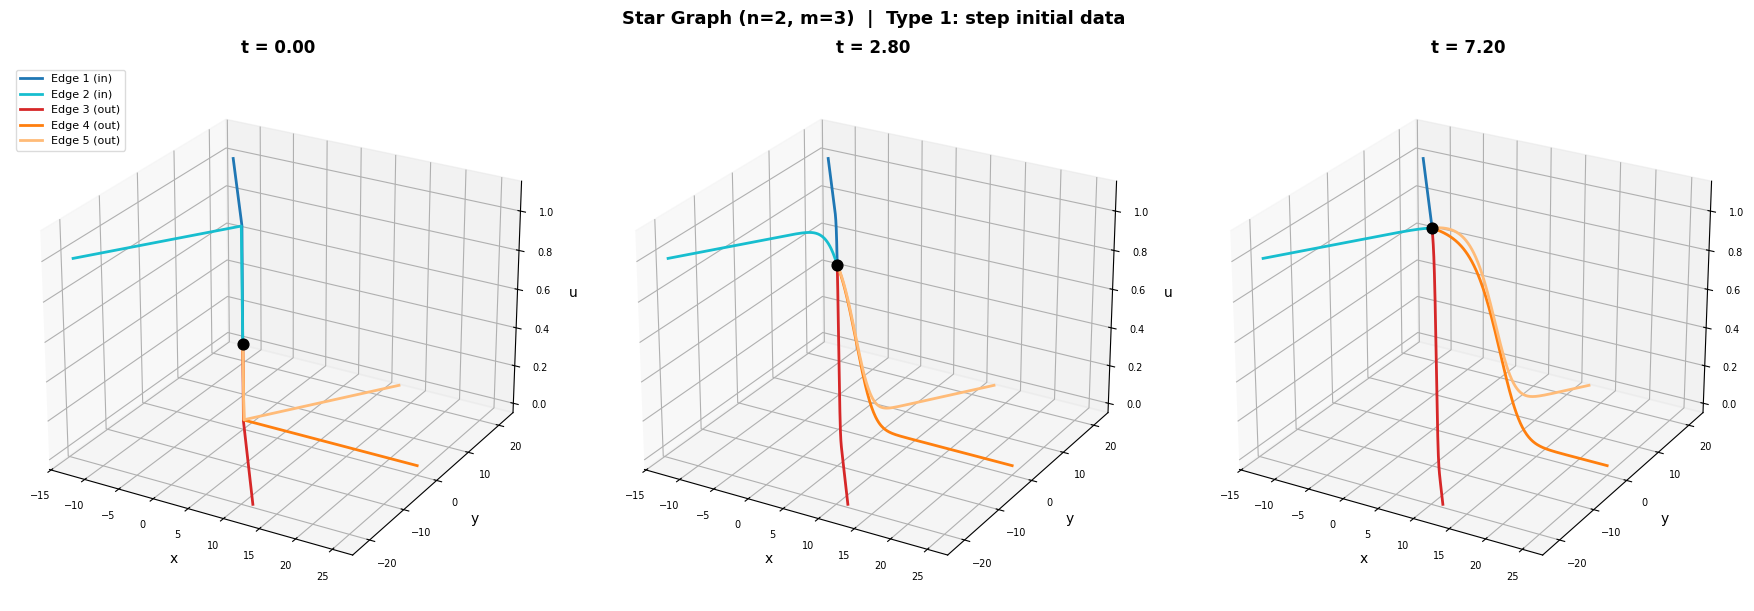


--- Type 2: exp(-1.0*x) outgoing ---
  t=3.0/12  Uv=0.9255
  t=6.0/12  Uv=0.9903
  t=9.0/12  Uv=0.9990
  t=12.0/12  Uv=0.9999


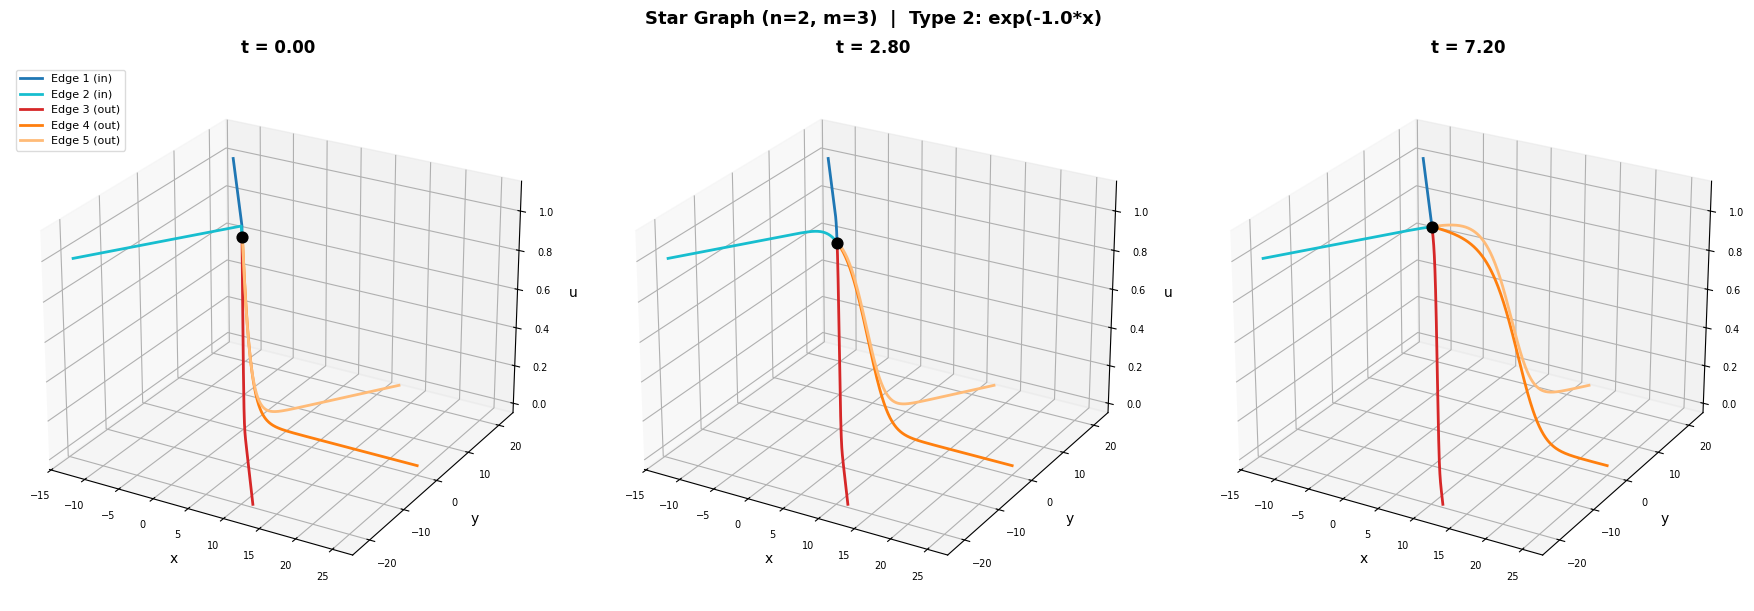

In [9]:
n, m = N_IN, N_OUT
LAM  = 1.0

# Accessors: pull the first outgoing edge from each snapshot format
get_star = lambda snap: snap[2][0]
get_ext  = lambda snap: snap[3][0]
get_tad  = lambda snap: snap[4]

print("=" * 55)
print(f"  Star Graph  (n={n} incoming,  m={m} outgoing)")
print("=" * 55)

print("\n--- Type 1: step initial data ---")
snap_star1 = simulate_star(n, m, *make_star_type1(n, m))
plot_star_3d(snap_star1, n, m,
             times_to_plot=(0, 3, 7),
             title=f'Star Graph (n={n}, m={m})  |  Type 1: step initial data',
             fname='output/star_type1_3d.png')

print(f"\n--- Type 2: exp(-{LAM}*x) outgoing ---")
snap_star2 = simulate_star(n, m, *make_star_type2(n, m, LAM))
plot_star_3d(snap_star2, n, m,
             times_to_plot=(0, 3, 7),
             title=f'Star Graph (n={n}, m={m})  |  Type 2: exp(-{LAM}*x)',
             fname='output/star_type2_3d.png')


## Cell 10 — Simulate & plot Graph 2: Extended Star Graph

The graph has two vertices connected by the middle edge (green).
Incoming edges (blue) fan from the left vertex; outgoing (red/orange) from the right.


  Extended Star  (n=2, middle, m=3)

--- Type 1 ---
  t=3.0/12  vL=0.9841  vR=0.6033
  t=6.0/12  vL=0.9976  vR=0.9394
  t=9.0/12  vL=0.9997  vR=0.9939
  t=12.0/12  vL=1.0000  vR=0.9994


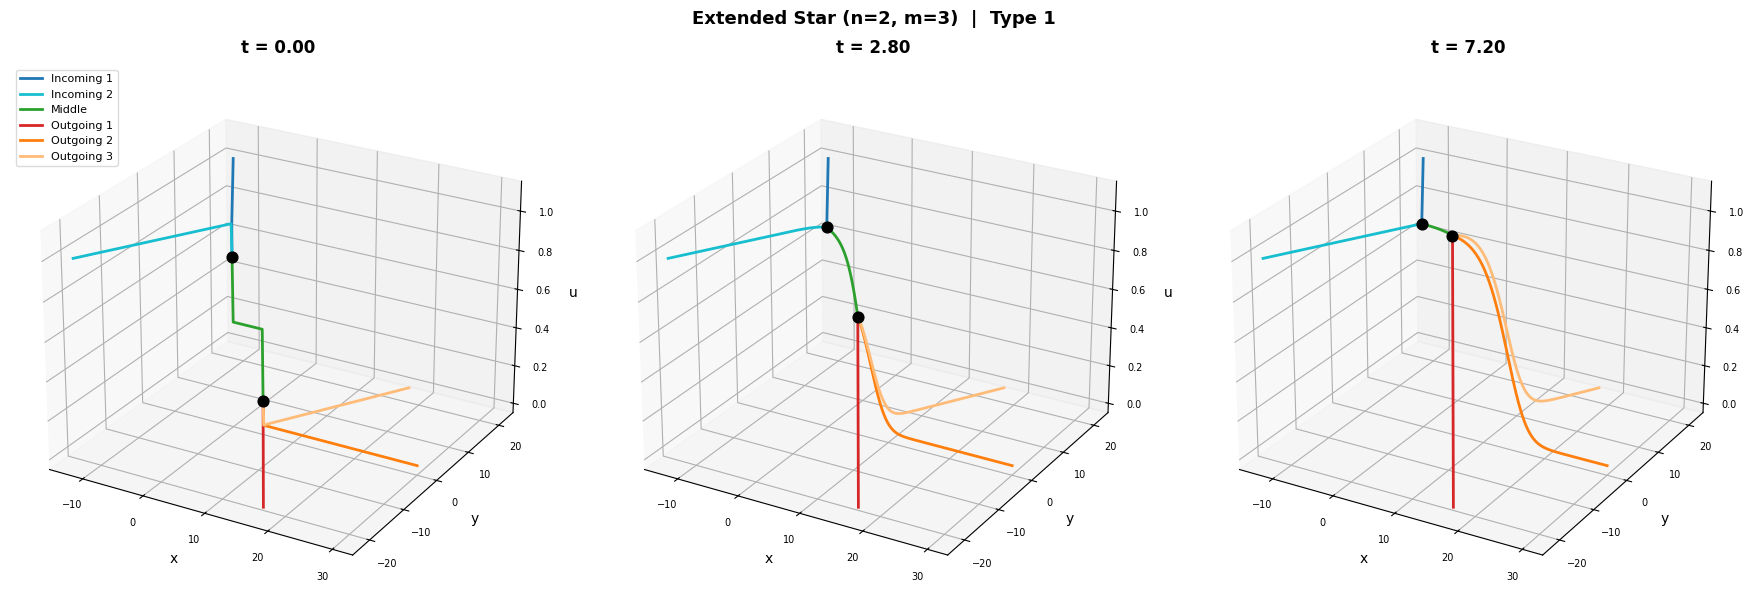


--- Type 2 (lambda=1.0) ---
  t=3.0/12  vL=0.9619  vR=0.2605
  t=6.0/12  vL=0.9935  vR=0.8152
  t=9.0/12  vL=0.9990  vR=0.9809
  t=12.0/12  vL=0.9999  vR=0.9983


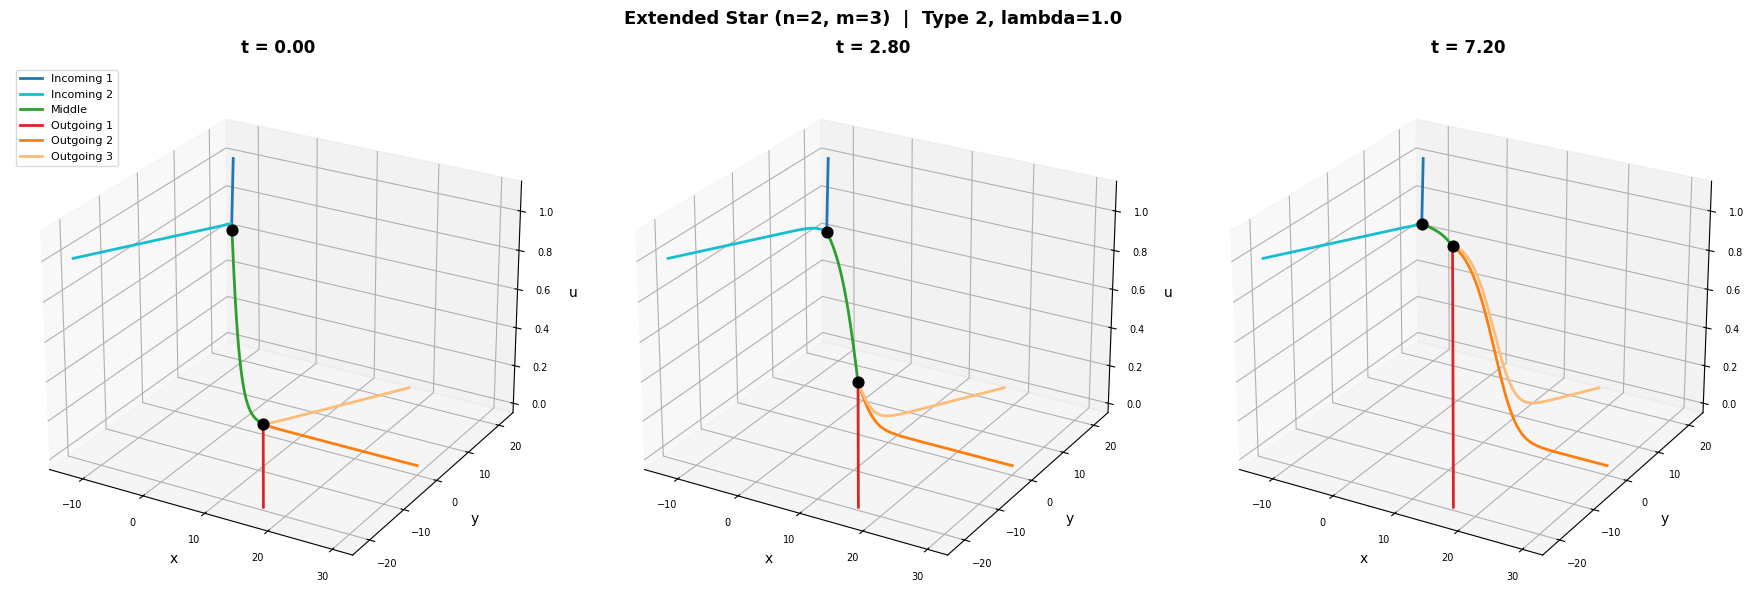

In [10]:
print("=" * 55)
print(f"  Extended Star  (n={n}, middle, m={m})")
print("=" * 55)

print("\n--- Type 1 ---")
snap_ext1 = simulate_extended_star(n, m, *make_ext_type1(n, m))
plot_extended_star_3d(snap_ext1, n, m,
                      times_to_plot=(0, 3, 7),
                      title=f'Extended Star (n={n}, m={m})  |  Type 1',
                      fname='output/extended_type1_3d.png')

print(f"\n--- Type 2 (lambda={LAM}) ---")
snap_ext2 = simulate_extended_star(n, m, *make_ext_type2(n, m, LAM))
plot_extended_star_3d(snap_ext2, n, m,
                      times_to_plot=(0, 3, 7),
                      title=f'Extended Star (n={n}, m={m})  |  Type 2, lambda={LAM}',
                      fname='output/extended_type2_3d.png')


## Cell 11 — Simulate & plot Graph 3: Tadpole Graph

The two loop edges (green shades) form a visible circle between the two vertices.
The incoming edge (blue) approaches from the left; the outgoing (red) exits right.


  Tadpole Graph  (1 in, 2 loop, 1 out)

--- Type 1 ---
  t=3.0/12  vL=0.9696  vR=0.8638
  t=6.0/12  vL=0.9977  vR=0.9844
  t=9.0/12  vL=0.9998  vR=0.9984
  t=12.0/12  vL=1.0000  vR=0.9998


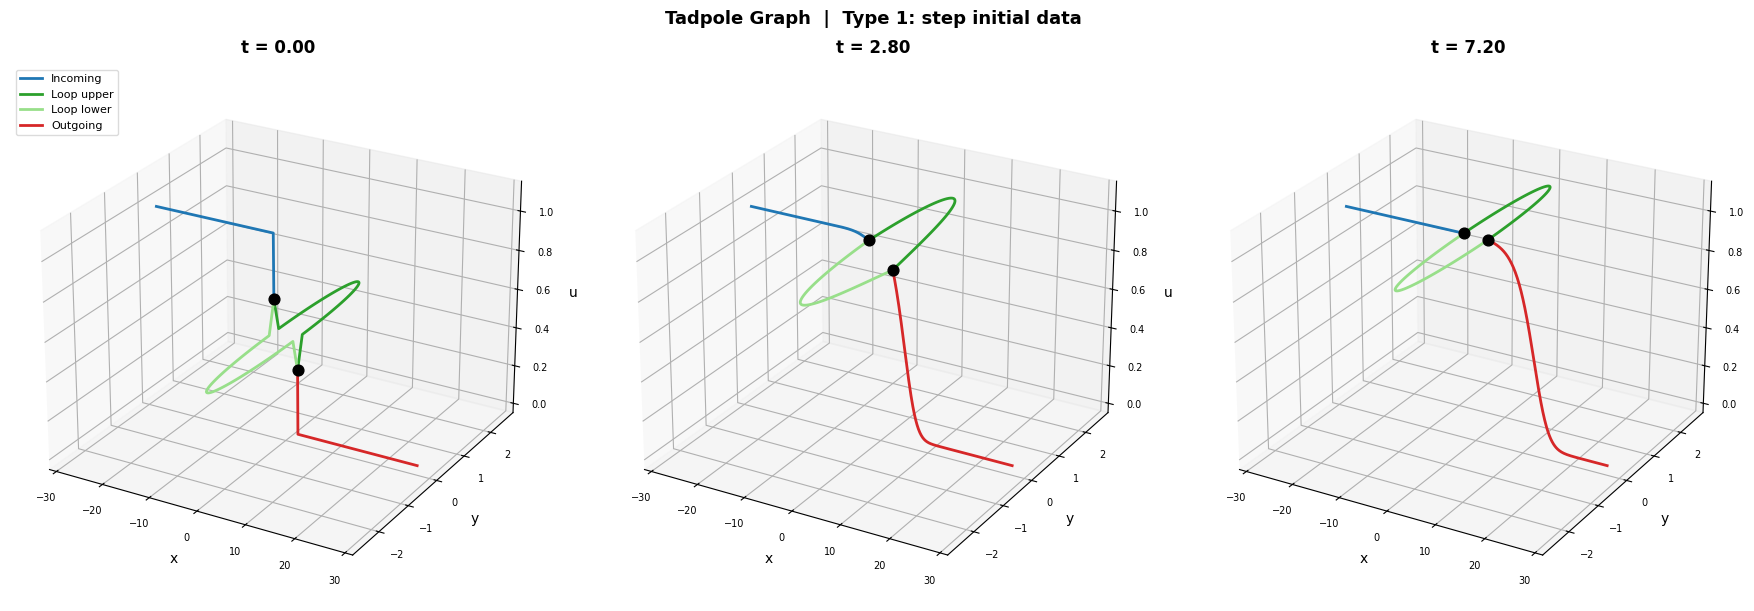


--- Type 2 (lambda=1.0) ---
  t=3.0/12  vL=0.9157  vR=0.5175
  t=6.0/12  vL=0.9904  vR=0.9432
  t=9.0/12  vL=0.9992  vR=0.9947
  t=12.0/12  vL=0.9999  vR=0.9995


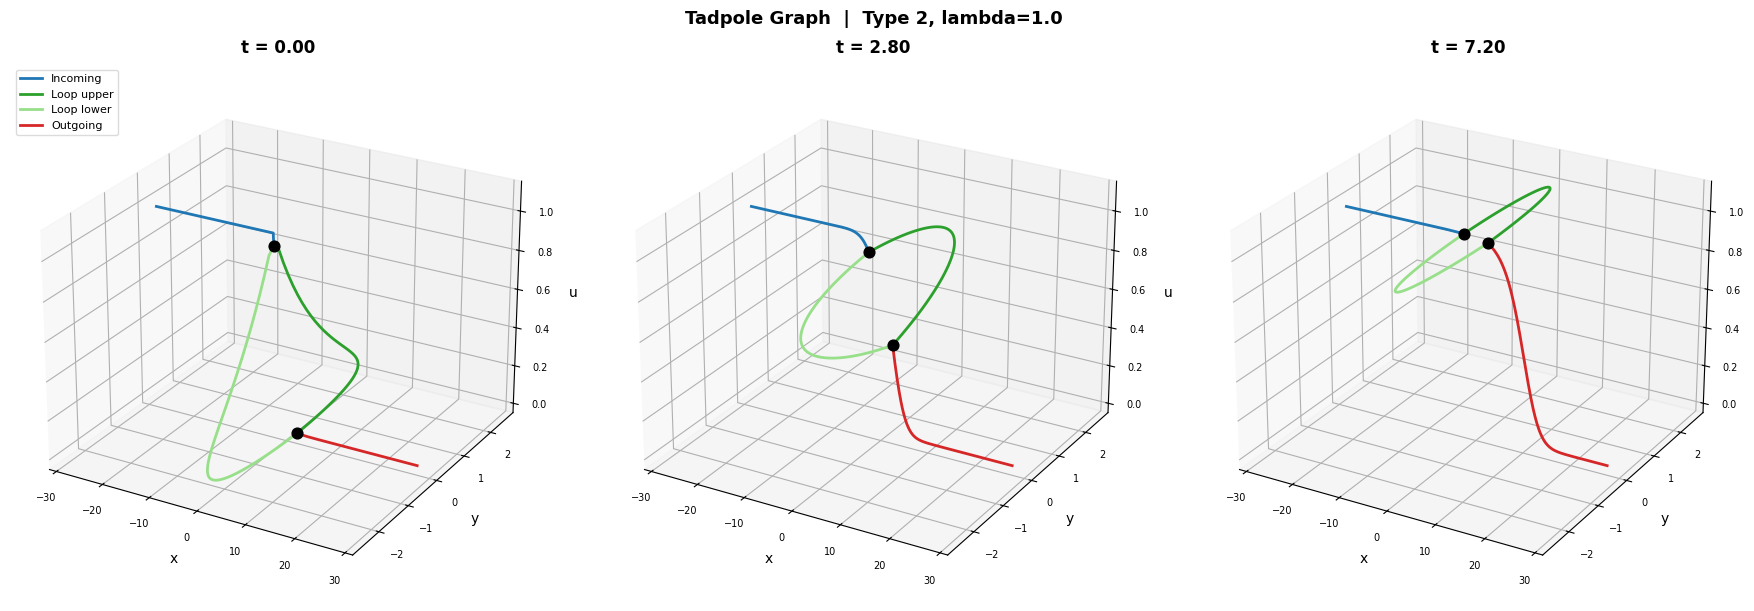

In [11]:
print("=" * 55)
print("  Tadpole Graph  (1 in, 2 loop, 1 out)")
print("=" * 55)

print("\n--- Type 1 ---")
snap_tad1 = simulate_tadpole(*make_tad_type1())
plot_tadpole_3d(snap_tad1,
                times_to_plot=(0, 3, 7),
                title='Tadpole Graph  |  Type 1: step initial data',
                fname='output/tadpole_type1_3d.png')

print(f"\n--- Type 2 (lambda={LAM}) ---")
snap_tad2 = simulate_tadpole(*make_tad_type2(LAM))
plot_tadpole_3d(snap_tad2,
                times_to_plot=(0, 3, 7),
                title=f'Tadpole Graph  |  Type 2, lambda={LAM}',
                fname='output/tadpole_type2_3d.png')


## Cell 12 — Wave speed estimation (level-set method)

Track the $u=0.5$ front on the outgoing edge and fit a linear slope.


In [12]:
print("Level-set speed estimation")
print("-" * 50)

ts1, ps1, c_star1 = level_set_speed(snap_star1, get_star)
te1, pe1, c_ext1  = level_set_speed(snap_ext1,  get_ext)
tt1, pt1, c_tad1  = level_set_speed(snap_tad1,  get_tad)

ts2, ps2, c_star2 = level_set_speed(snap_star2, get_star)
te2, pe2, c_ext2  = level_set_speed(snap_ext2,  get_ext)
tt2, pt2, c_tad2  = level_set_speed(snap_tad2,  get_tad)

print(f"\nType 1 (step):")
print(f"  Star graph   : c = {c_star1:.4f}")
print(f"  Extended star: c = {c_ext1:.4f}")
print(f"  Tadpole      : c = {c_tad1:.4f}")

print(f"\nType 2 (lambda={LAM}):")
print(f"  Star graph   : c = {c_star2:.4f}")
print(f"  Extended star: c = {c_ext2:.4f}")
print(f"  Tadpole      : c = {c_tad2:.4f}")

print(f"\nTheoretical c* = 2.0")


Level-set speed estimation
--------------------------------------------------

Type 1 (step):
  Star graph   : c = 1.7556
  Extended star: c = 1.7911
  Tadpole      : c = 1.7543

Type 2 (lambda=1.0):
  Star graph   : c = 1.8740
  Extended star: c = 1.9784
  Tadpole      : c = 1.8408

Theoretical c* = 2.0


## Cell 13 — Plot: front tracking & speed comparison bar chart


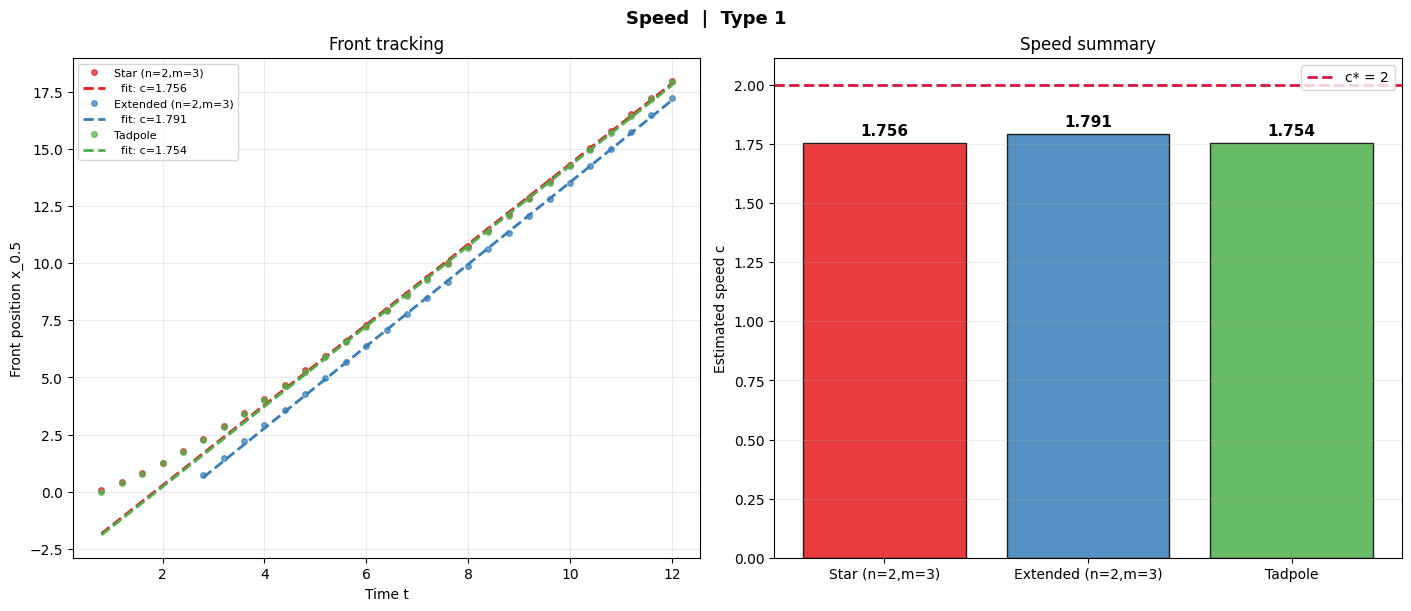

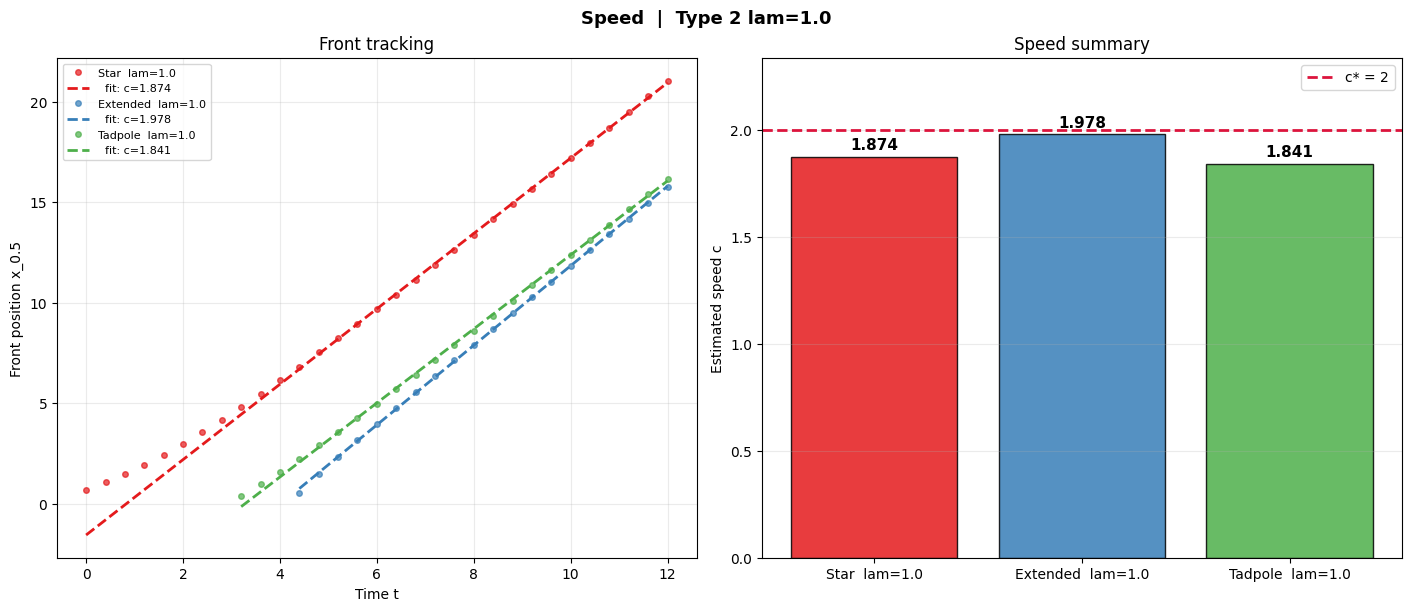

In [13]:
def plot_speed_comparison(results, title='Speed Comparison', fname=None):
    fig, (ax_t, ax_b) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    valid = []
    for label, times, positions, speed, color in results:
        if len(times) < 2:
            continue
        ax_t.plot(times, positions, 'o', color=color, ms=4, alpha=0.7, label=label)
        if not np.isnan(speed):
            t_cut = 0.35 * times[-1]
            mask  = times >= t_cut
            b     = np.mean(positions[mask] - speed * times[mask])
            t_fit = np.linspace(times[0], times[-1], 200)
            ax_t.plot(t_fit, speed*t_fit + b, '--', color=color, lw=2,
                      label=f'  fit: c={speed:.3f}')
            valid.append((label, speed, color))
    ax_t.set(xlabel='Time t', ylabel='Front position x_0.5', title='Front tracking')
    ax_t.legend(fontsize=8)
    ax_t.grid(True, alpha=0.25)
    if valid:
        lbls = [v[0] for v in valid]
        spds = [v[1] for v in valid]
        clrs = [v[2] for v in valid]
        bars = ax_b.bar(lbls, spds, color=clrs, alpha=0.85, edgecolor='k')
        ax_b.axhline(2.0, color='crimson', lw=2, ls='--', label='c* = 2')
        for bar, s in zip(bars, spds):
            ax_b.text(bar.get_x() + bar.get_width()/2, s + 0.02,
                      f'{s:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        ax_b.set(ylabel='Estimated speed c', title='Speed summary')
        ax_b.legend(fontsize=10)
        ax_b.set_ylim(0, max(spds) * 1.18)
        ax_b.grid(True, axis='y', alpha=0.25)
    if fname: fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

res_type1 = [
    (f'Star (n={n},m={m})',     ts1, ps1, c_star1, COLORS[0]),
    (f'Extended (n={n},m={m})', te1, pe1, c_ext1,  COLORS[1]),
    ('Tadpole',                 tt1, pt1, c_tad1,  COLORS[2]),
]
res_type2 = [
    (f'Star  lam={LAM}',     ts2, ps2, c_star2, COLORS[0]),
    (f'Extended  lam={LAM}', te2, pe2, c_ext2,  COLORS[1]),
    (f'Tadpole  lam={LAM}',  tt2, pt2, c_tad2,  COLORS[2]),
]
plot_speed_comparison(res_type1, title='Speed  |  Type 1', fname='output/speed_type1.png')
plot_speed_comparison(res_type2, title=f'Speed  |  Type 2 lam={LAM}', fname='output/speed_type2.png')


## Cell 14 — Space–time heatmaps on the outgoing edge


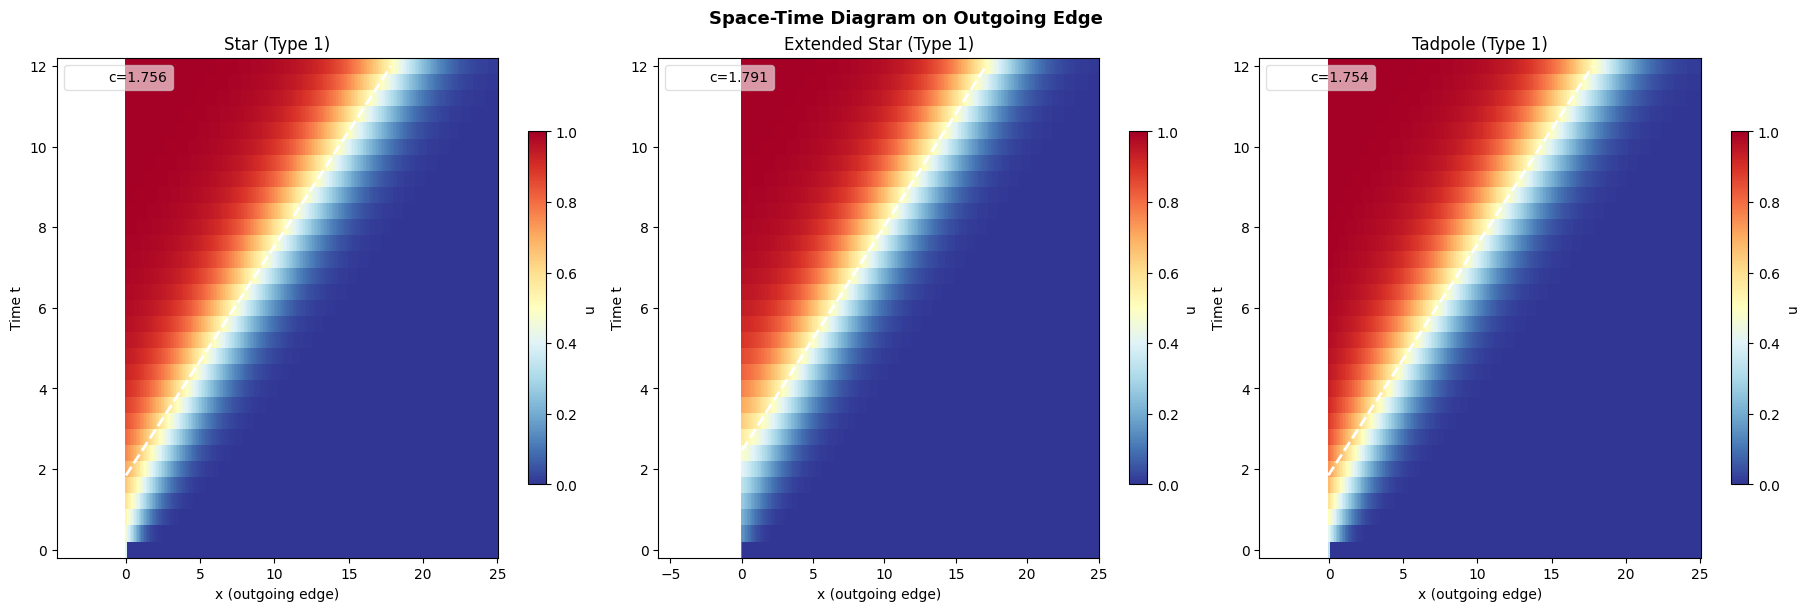

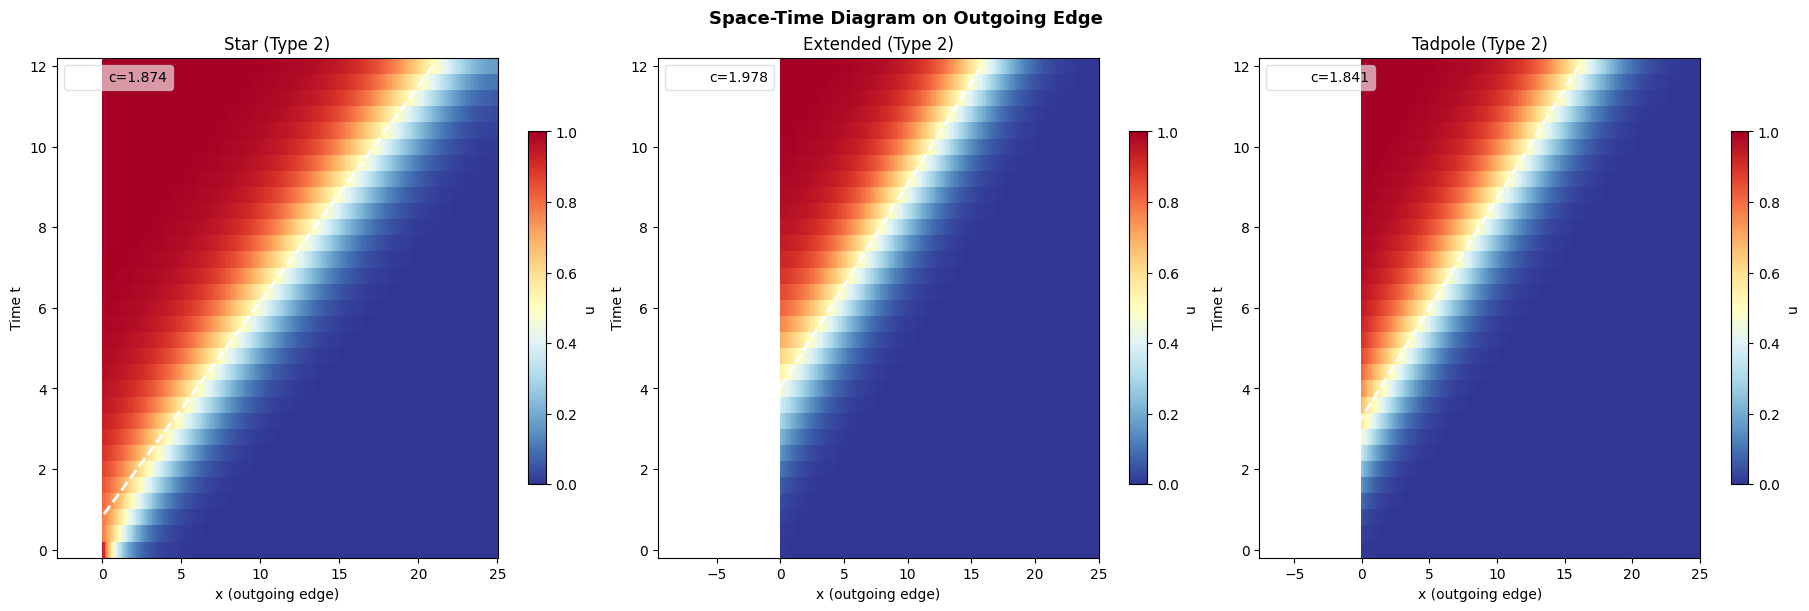

In [14]:
def plot_spacetime(snaps_list, labels, get_fns, fname=None):
    fig, axes = plt.subplots(1, len(snaps_list), figsize=(6*len(snaps_list), 6),
                             constrained_layout=True)
    fig.suptitle('Space-Time Diagram on Outgoing Edge', fontsize=13, fontweight='bold')
    for ax, snaps, label, get_fn in zip(axes, snaps_list, labels, get_fns):
        times = np.array([s[0] for s in snaps])
        U_mat = np.zeros((len(times), N+1))
        for ti, snap in enumerate(snaps):
            U_mat[ti] = get_fn(snap)
        im = ax.pcolormesh(X_OUT, times, U_mat,
                           cmap='RdYlBu_r', vmin=0, vmax=1, shading='auto')
        fig.colorbar(im, ax=ax, label='u', fraction=0.04)
        ls_t, ls_pos, speed = level_set_speed(snaps, get_fn)
        if len(ls_pos) > 1 and not np.isnan(speed):
            mask = ls_t >= 0.35 * ls_t[-1]
            b    = np.mean(ls_pos[mask] - speed * ls_t[mask])
            ax.plot(speed*times + b, times, 'w--', lw=2, label=f'c={speed:.3f}')
            ax.legend(loc='upper left', fontsize=10, framealpha=0.6)
        ax.set(xlabel='x (outgoing edge)', ylabel='Time t', title=label)
    if fname: fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_spacetime([snap_star1, snap_ext1, snap_tad1],
               ['Star (Type 1)', 'Extended Star (Type 1)', 'Tadpole (Type 1)'],
               [get_star, get_ext, get_tad], fname='output/spacetime_type1.png')
plot_spacetime([snap_star2, snap_ext2, snap_tad2],
               ['Star (Type 2)', 'Extended (Type 2)', 'Tadpole (Type 2)'],
               [get_star, get_ext, get_tad], fname='output/spacetime_type2.png')


## Cell 15 — Instantaneous speed convergence toward $c^* = 2$


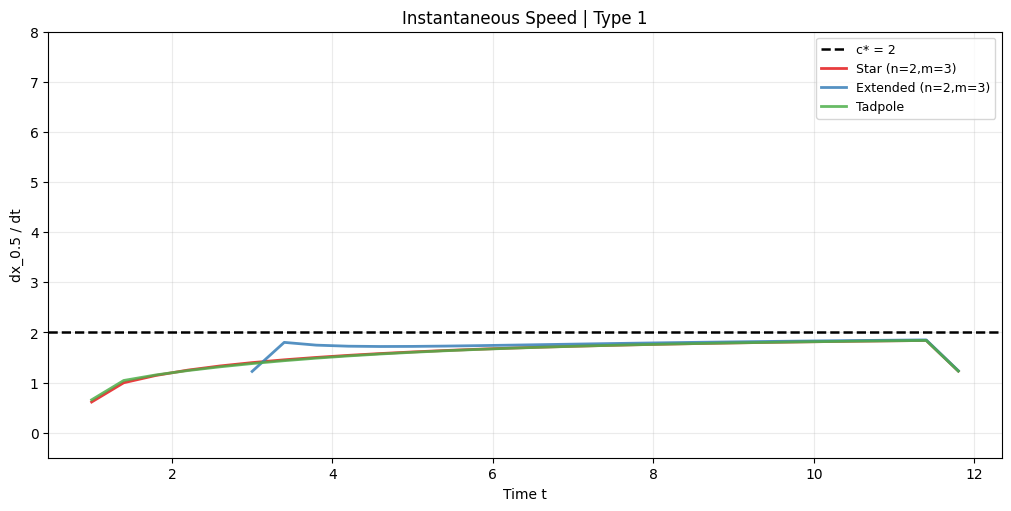

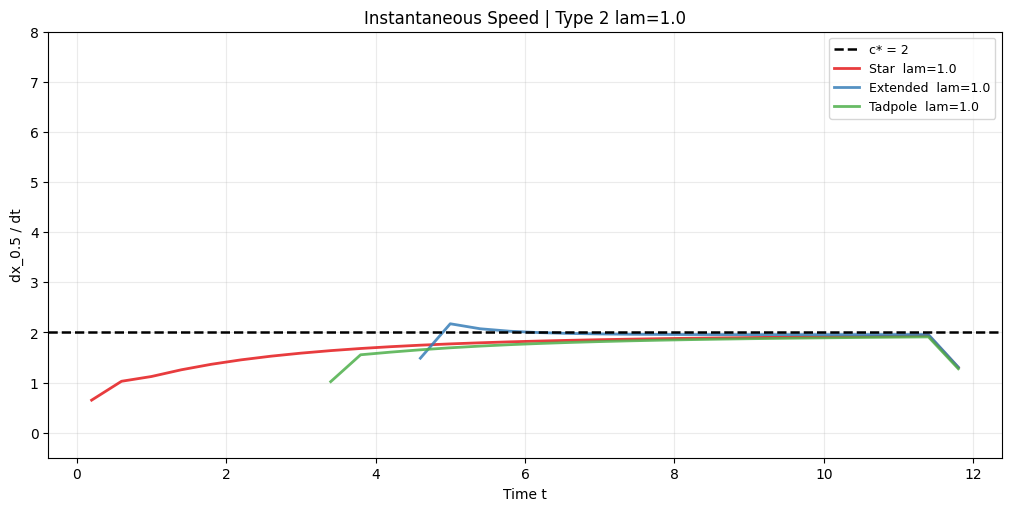

In [15]:
def plot_instantaneous_speed(results, title='Instantaneous Speed', fname=None):
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.axhline(2.0, color='k', lw=1.8, ls='--', zorder=5, label='c* = 2')
    for label, times, positions, speed, color in results:
        if len(times) < 5:
            continue
        dt_v  = np.diff(times)
        dx_v  = np.diff(positions)
        good  = dt_v > 1e-10
        t_mid = 0.5 * (times[:-1][good] + times[1:][good])
        v_inst = dx_v[good] / dt_v[good]
        if len(v_inst) > 5:
            v_inst = np.convolve(v_inst, np.ones(3)/3, mode='same')
        ax.plot(t_mid, v_inst, color=color, lw=2, alpha=0.85, label=label)
    ax.set(xlabel='Time t', ylabel='dx_0.5 / dt', title=title, ylim=(-0.5, 8))
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.25)
    if fname: fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_instantaneous_speed(res_type1, title='Instantaneous Speed | Type 1',
                         fname='output/inst_speed_type1.png')
plot_instantaneous_speed(res_type2, title=f'Instantaneous Speed | Type 2 lam={LAM}',
                         fname='output/inst_speed_type2.png')


## Cell 16 — $\lambda$ study: how decay rate affects wave speed


In [16]:
lambdas = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5]
lambda_results = []

print(f"{'lam':>5}  {'c_star':>8}  {'c_ext':>8}  {'c_tad':>8}  {'c_theory':>10}")
print("-" * 48)
for lam in lambdas:
    snp = simulate_star(n, m, *make_star_type2(n, m, lam), verbose=False)
    _, _, c_s = level_set_speed(snp, get_star)
    snp = simulate_extended_star(n, m, *make_ext_type2(n, m, lam), verbose=False)
    _, _, c_e = level_set_speed(snp, get_ext)
    snp = simulate_tadpole(*make_tad_type2(lam), verbose=False)
    _, _, c_t = level_set_speed(snp, get_tad)
    th = theoretical_speed(lam)
    lambda_results.append((lam, c_s, c_e, c_t))
    print(f"{lam:>5.2f}  {c_s:>8.3f}  {c_e:>8.3f}  {c_t:>8.3f}  {th:>10.3f}")


  lam    c_star     c_ext     c_tad    c_theory
------------------------------------------------
 0.50     2.570     2.572     2.552       2.500
 0.75     2.078     2.103     1.995       2.083
 1.00     1.874     1.978     1.841       2.000
 1.25     1.813     1.909     1.787       2.050
 1.50     1.787     1.886     1.763       2.167
 2.00     1.768     1.863     1.743       2.500
 2.50     1.761     1.863     1.736       2.900


## Cell 17 — Plot: $c$ vs $\lambda$ compared to theory $c(\lambda)=\lambda+1/\lambda$


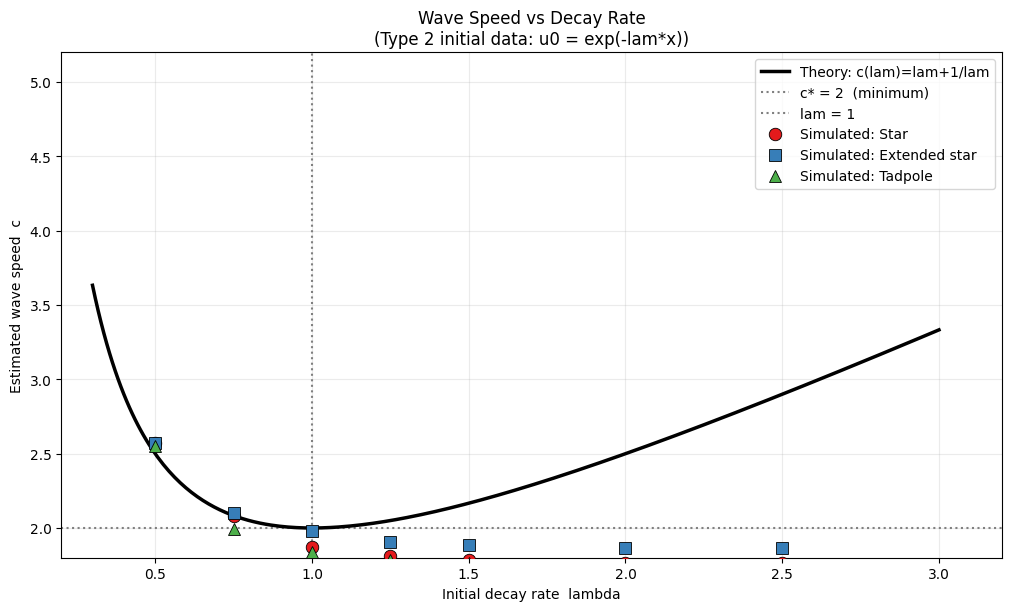

In [17]:
def plot_lambda_study(lambda_results, fname=None):
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    lam_th = np.linspace(0.3, 3.0, 300)
    c_th   = np.maximum(2.0, lam_th + 1.0/lam_th)
    ax.plot(lam_th, c_th, 'k-', lw=2.5, zorder=5, label='Theory: c(lam)=lam+1/lam')
    ax.axhline(2.0, color='gray', ls=':', lw=1.5, label='c* = 2  (minimum)')
    ax.axvline(1.0, color='gray', ls=':', lw=1.5, label='lam = 1')
    for gi, (gname, marker, color) in enumerate(
            zip(['Star', 'Extended star', 'Tadpole'], ['o', 's', '^'], COLORS)):
        lams = [r[0]    for r in lambda_results]
        spds = [r[gi+1] for r in lambda_results]
        valid = [(l, s) for l, s in zip(lams, spds) if not np.isnan(s)]
        if valid:
            lv, sv = zip(*valid)
            ax.plot(lv, sv, marker, color=color, ms=9, label=f'Simulated: {gname}',
                    zorder=6, markeredgecolor='k', markeredgewidth=0.6)
    ax.set(xlabel='Initial decay rate  lambda', ylabel='Estimated wave speed  c',
           title='Wave Speed vs Decay Rate\n(Type 2 initial data: u0 = exp(-lam*x))',
           xlim=(0.2, 3.2), ylim=(1.8, 5.2))
    ax.legend(fontsize=10);  ax.grid(True, alpha=0.25)
    if fname: fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_lambda_study(lambda_results, fname='output/lambda_vs_speed.png')


## Cell 18 — Late-time profile shape near the vertex

Log-scale plot reveals the exponential leading edge.
Deviations from parallel lines show where the vertex distorts the wave profile.


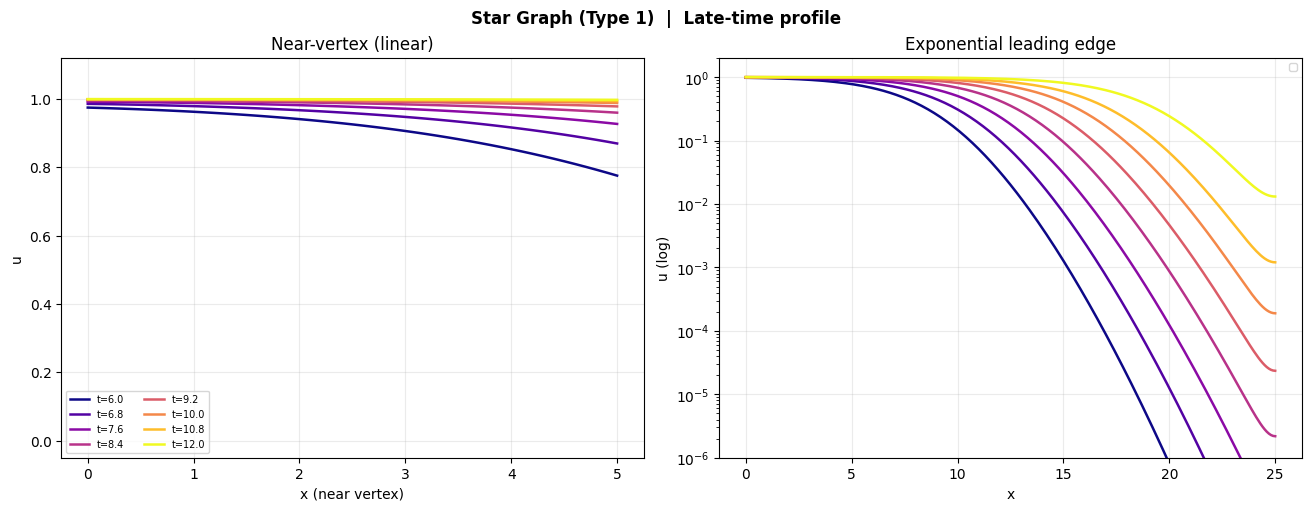

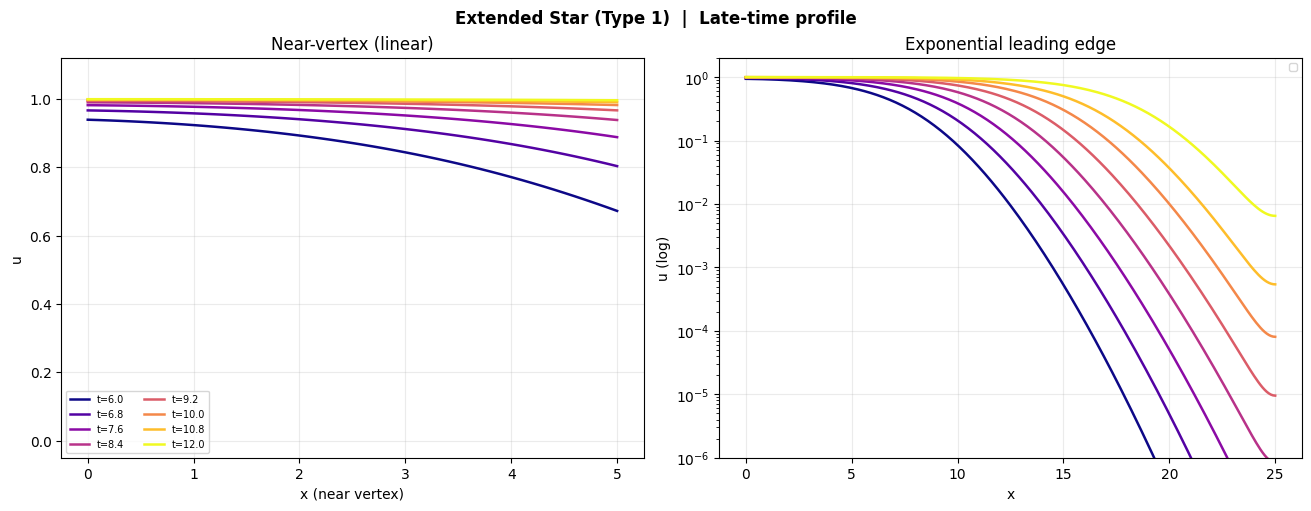

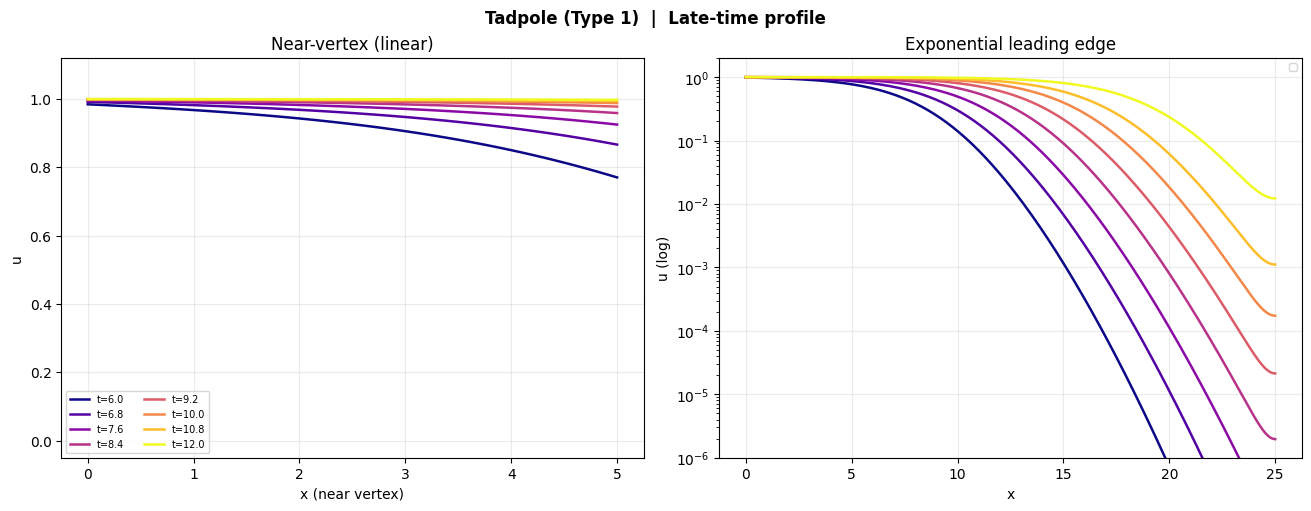

In [18]:
def plot_vertex_profiles(snapshots, get_out_fn, title, fname=None):
    n_show = 8
    half   = len(snapshots) // 2
    idxs   = np.linspace(half, len(snapshots)-1, n_show, dtype=int)
    colors = snap_colors(n_show)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    fig.suptitle(title + '  |  Late-time profile', fontsize=12, fontweight='bold')
    quarter = N // 5
    for c, snap in zip(colors, [snapshots[i] for i in idxs]):
        t = snap[0]
        u = get_out_fn(snap)
        axes[0].plot(X_OUT[:quarter+1], u[:quarter+1], color=c, lw=1.8, label=f't={t:.1f}')
        axes[1].semilogy(X_OUT, np.maximum(u, 1e-10), color=c, lw=1.8)
    axes[0].set(xlabel='x (near vertex)', ylabel='u',
                title='Near-vertex (linear)', ylim=(-0.05, 1.12))
    axes[1].set(xlabel='x', ylabel='u (log)', title='Exponential leading edge', ylim=(1e-6, 2))
    for ax in axes:
        ax.legend(fontsize=7, ncol=2);  ax.grid(True, alpha=0.25)
    if fname: fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_vertex_profiles(snap_star1, get_star, 'Star Graph (Type 1)',
                     fname='output/vertex_star.png')
plot_vertex_profiles(snap_ext1,  get_ext,  'Extended Star (Type 1)',
                     fname='output/vertex_extended.png')
plot_vertex_profiles(snap_tad1,  get_tad,  'Tadpole (Type 1)',
                     fname='output/vertex_tadpole.png')


## Cell 19 — Final results summary

In [19]:
print("=" * 72)
print("  FINAL RESULTS SUMMARY")
print("=" * 72)
print(f"  {'Graph':<25} {'Init':<18} {'c simulated':>13} {'c theory':>10} {'err':>6}")
print("  " + "-" * 70)
rows = [
    ('Star',          'Type 1 (step)',    c_star1, 2.0),
    ('Extended star', 'Type 1 (step)',    c_ext1,  2.0),
    ('Tadpole',       'Type 1 (step)',    c_tad1,  2.0),
    ('Star',          f'Type 2 lam={LAM}', c_star2, theoretical_speed(LAM)),
    ('Extended star', f'Type 2 lam={LAM}', c_ext2,  theoretical_speed(LAM)),
    ('Tadpole',       f'Type 2 lam={LAM}', c_tad2,  theoretical_speed(LAM)),
]
for graph, typ, c_sim, c_th in rows:
    err = abs(c_sim - c_th)
    print(f"  {graph:<25} {typ:<18} {c_sim:>13.4f} {c_th:>10.4f} {err:>5.3f}")
print()
print("  Notes:")
print("  * Speeds below 2 for Type 1 are expected: wave is still in transient phase.")
print("  * Instantaneous speed plot (Cell 15) shows convergence toward c*=2.")
print("  * Large lambda underestimates: fast front exits domain before establishing.")
print("=" * 72)


  FINAL RESULTS SUMMARY
  Graph                     Init                 c simulated   c theory    err
  ----------------------------------------------------------------------
  Star                      Type 1 (step)             1.7556     2.0000 0.244
  Extended star             Type 1 (step)             1.7911     2.0000 0.209
  Tadpole                   Type 1 (step)             1.7543     2.0000 0.246
  Star                      Type 2 lam=1.0            1.8740     2.0000 0.126
  Extended star             Type 2 lam=1.0            1.9784     2.0000 0.022
  Tadpole                   Type 2 lam=1.0            1.8408     2.0000 0.159

  Notes:
  * Speeds below 2 for Type 1 are expected: wave is still in transient phase.
  * Instantaneous speed plot (Cell 15) shows convergence toward c*=2.
  * Large lambda underestimates: fast front exits domain before establishing.
